# Fase 1: Predicción de Riesgo de Default — LendingClub
**Curso:** AI Impact Analysis in Business  
**Objetivo de negocio:** Minimizar Falsos Positivos (créditos aprobados a clientes morosos)  
**Estrategia:** Enriquecimiento macroeconómico (FRED) + ajuste de umbral de decisión

## 0. Imports y configuración global

In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# ── Modelos ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

# ── Configuración global ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# Rutas del proyecto
DATA_RAW       = os.path.join('data', 'accepted_2007_to_2018Q4.csv.gz')
DATA_MACRO_CPI = os.path.join('data', 'CPIAUCSL.csv')
DATA_MACRO_FED = os.path.join('data', 'FEDFUNDS.csv')
DATA_MACRO_UNE = os.path.join('data', 'UNRATE.csv')
DIR_PROCESSED  = os.path.join('data', 'processed')

# Creamos los directorios de salida si no existen
os.makedirs(DIR_PROCESSED, exist_ok=True)

print("Librerías cargadas correctamente.")
print(f"Directorio de datos procesados: '{DIR_PROCESSED}/'")

Librerías cargadas correctamente.
Directorio de datos procesados: 'data\processed/'


## 1. Carga del dataset LendingClub

Seleccionamos únicamente las columnas relevantes con `usecols` para evitar cargar las 151 columnas del CSV
en memoria, lo que reduciría el tiempo de lectura a la mitad en datasets de este tamaño (~2.2 M filas).

In [3]:
# Columnas seleccionadas: variables del solicitante + fechas para ingeniería temporal
COLS_USADAS = [
    'loan_amnt',            # Importe solicitado
    'term',                 # Plazo del préstamo (36 o 60 meses)
    'int_rate',             # Tipo de interés asignado por LendingClub
    'installment',          # Cuota mensual
    'grade',                # Grado de riesgo interno (A–G)
    'emp_length',           # Antigüedad laboral declarada
    'home_ownership',       # Tipo de vivienda (MORTGAGE, RENT, OWN…)
    'annual_inc',           # Ingresos anuales declarados
    'verification_status',  # Estado de verificación de ingresos
    'issue_d',              # Fecha de emisión del préstamo (clave para el merge macro)
    'loan_status',          # TARGET: resultado final del préstamo
    'purpose',              # Propósito del préstamo declarado por el cliente
    'dti',                  # Ratio deuda/ingresos (Debt-To-Income)
    'delinq_2yrs',          # Número de impagos en los últimos 2 años
    'earliest_cr_line',     # Fecha del primer crédito (para calcular antigüedad crediticia)
    'fico_range_low',       # Límite inferior del rango FICO Score
    'fico_range_high',      # Límite superior del rango FICO Score
    'open_acc',             # Número de cuentas de crédito abiertas
    'pub_rec',              # Registros públicos negativos (quiebras, embargos…)
    'revol_bal',            # Saldo de crédito revolving
    'revol_util',           # Porcentaje de utilización del crédito revolving
    'total_acc',            # Total de cuentas de crédito históricas
    'inq_last_6mths',       # Consultas a bureaus de crédito en últimos 6 meses
]

print("Cargando dataset... (puede tardar varios minutos por el tamaño del archivo)")
df_raw = pd.read_csv(DATA_RAW, usecols=COLS_USADAS, low_memory=False)

print(f"Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

Cargando dataset... (puede tardar varios minutos por el tamaño del archivo)
Dataset cargado: 2,260,701 filas × 23 columnas


,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,...,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,3600.0,36 months,13.99,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,...,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0
1,24700.0,36 months,11.99,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,...,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0
2,20000.0,60 months,10.78,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,...,0.0,Aug-2000,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0


## 2. Definición y limpieza del TARGET

La variable `loan_status` contiene múltiples categorías. Definimos:
- **Default = 1:** Charged Off, Default, Late (31-120 days) — pérdida real o inminente para el banco
- **No Default = 0:** Fully Paid — crédito saldado correctamente

**Excluimos** los préstamos 'Current' y 'In Grace Period' porque su resultado final es aún desconocido — incluirlos introduciría ruido en el modelo.

In [4]:
print("Distribución original de loan_status:")
print(df_raw['loan_status'].value_counts())

# Mapeamos únicamente los estados con resultado final conocido.
# Los estados ambiguos (Current, In Grace Period, Late 16-30d) se excluyen
# asignándoles NaN, que luego se eliminan con dropna.
STATUS_MAP = {
    'Charged Off'                                          : 1,
    'Default'                                              : 1,
    'Late (31-120 days)'                                   : 1,
    'Does not meet the credit policy. Status:Charged Off'  : 1,
    'Fully Paid'                                           : 0,
    'Does not meet the credit policy. Status:Fully Paid'   : 0,
    # Estados con resultado desconocido → NaN → excluidos
    'Current'           : np.nan,
    'In Grace Period'   : np.nan,
    'Late (16-30 days)' : np.nan,
}

df_raw['target'] = df_raw['loan_status'].map(STATUS_MAP)
df = df_raw.dropna(subset=['target']).copy()
df['target'] = df['target'].astype(np.int8)   # int8 ahorra ~3x memoria vs int64

print(f"\nRegistros con resultado conocido: {len(df):,}")
print(f"\nDistribución del target:")
print(df['target'].value_counts(normalize=True).round(3))
print("\n→ Desbalanceo esperado: ~80% No Default / ~20% Default")

Distribución original de loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Registros con resultado conocido: 1,369,566

Distribución del target:
target
0    0.788
1    0.212
Name: proportion, dtype: float64

→ Desbalanceo esperado: ~80% No Default / ~20% Default


## 3. Ingeniería de características temporales

Calculamos `meses_desde_primer_credito`: número de meses entre el primer crédito del cliente y la fecha de emisión del préstamo actual. Captura la **antigüedad crediticia** — un cliente con historial largo es estadísticamente menos riesgoso.

In [5]:
# LendingClub usa el formato 'MMM-YYYY' (ej: 'Dec-2015') en ambas columnas de fecha.
# pd.to_datetime con format explícito es hasta 50x más rápido que la inferencia automática.
df['issue_d_dt']          = pd.to_datetime(df['issue_d'],          format='%b-%Y')
df['earliest_cr_line_dt'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

# Diferencia en meses: (años de diferencia × 12) + meses residuales
df['meses_desde_primer_credito'] = (
    (df['issue_d_dt'].dt.year  - df['earliest_cr_line_dt'].dt.year)  * 12
    + df['issue_d_dt'].dt.month - df['earliest_cr_line_dt'].dt.month
)

# Llaves temporales para el merge con datos macroeconómicos (Sección 4)
df['issue_mes']  = df['issue_d_dt'].dt.month
df['issue_anio'] = df['issue_d_dt'].dt.year

print("Feature temporal creada con éxito:")
print(df[['issue_d', 'earliest_cr_line', 'meses_desde_primer_credito']].head(5))
print(
    f"\nEstadísticas: "
    f"media={df['meses_desde_primer_credito'].mean():.0f} meses, "
    f"mediana={df['meses_desde_primer_credito'].median():.0f} meses"
)

Feature temporal creada con éxito:
    issue_d earliest_cr_line  meses_desde_primer_credito
0  Dec-2015         Aug-2003                       148.0
1  Dec-2015         Dec-1999                       192.0
2  Dec-2015         Aug-2000                       184.0
4  Dec-2015         Jun-1998                       210.0
5  Dec-2015         Oct-1987                       338.0

Estadísticas: media=195 meses, mediana=177 meses


## 4. Inyección macroeconómica (datos FRED)

Enriquecemos el dataset con el contexto económico del mes de emisión. **Rellena el DataFrame `df_macro` con tus datos descargados del FRED.** El bloque de merge está listo para ejecutarse una vez completado.

In [6]:
print("Cargando archivos CSV locales del FRED...")

df_cpi   = pd.read_csv(DATA_MACRO_CPI)
df_fed   = pd.read_csv(DATA_MACRO_FED)
df_unemp = pd.read_csv(DATA_MACRO_UNE)

# Parseamos la columna de fecha en los tres DataFrames con format explícito
for frame in (df_cpi, df_fed, df_unemp):
    frame['observation_date'] = pd.to_datetime(frame['observation_date'])

# Consolidamos los tres indicadores en un único DataFrame macro mediante inner joins
df_macro = (
    df_cpi
    .merge(df_fed,   on='observation_date', how='inner')
    .merge(df_unemp, on='observation_date', how='inner')
)

# Filtramos la ventana temporal 2007–2018 (rango del dataset de LendingClub)
mask_periodo = df_macro['observation_date'].dt.year.between(2007, 2018)
df_macro = df_macro.loc[mask_periodo].copy()

# Renombramos a nombres semánticamente claros y en inglés (consistencia del dataset)
df_macro.rename(columns={
    'CPIAUCSL' : 'inflation',
    'FEDFUNDS' : 'federal_funds_rate',
    'UNRATE'   : 'unemployment_rate',
}, inplace=True)

# Extraemos las llaves de cruce (mes y año) y eliminamos la columna de fecha
df_macro['issue_mes']  = df_macro['observation_date'].dt.month
df_macro['issue_anio'] = df_macro['observation_date'].dt.year
df_macro.drop(columns='observation_date', inplace=True)

print("Datos macroeconómicos cargados y preparados con éxito:")
print(df_macro.head())

Cargando archivos CSV locales del FRED...
Datos macroeconómicos cargados y preparados con éxito:
     inflation  federal_funds_rate  unemployment_rate  issue_mes  issue_anio
630    203.437                5.25                4.6          1        2007
631    204.226                5.26                4.5          2        2007
632    205.288                5.26                4.4          3        2007
633    205.904                5.25                4.5          4        2007
634    206.755                5.25                4.4          5        2007


En el dataset original de LendingClub, solo contamos con una "foto estática" del cliente: su sueldo, su historial crediticio y su nivel de deuda. Sin embargo, el riesgo de crédito **no solo depende de quién es el cliente, sino también de cuándo decide solicitar el préstamo**. Un mismo perfil crediticio puede comportarse de manera radicalmente distinta según el contexto macroeconómico en el que se encuentre.

---

### **1. Contexto de la Capacidad de Pago**
Imagina a un cliente con un sueldo de **$3,000 mensuales**. En un entorno de baja inflación (por ejemplo, al 2%), ese ingreso le permite cubrir sus gastos básicos y aún destinar parte a pagar su préstamo. Sin embargo, si la inflación se dispara al **8%**, ese mismo sueldo pierde valor real. La gasolina, los alimentos y los servicios básicos aumentan, reduciendo su renta disponible. De repente, ese cliente que antes podía pagar puntualmente, se ve obligado a priorizar sus necesidades básicas sobre su deuda.

**¿Por qué esto es relevante para el modelo?**
Al incorporar la variable `inflation`, estamos incluyendo un **"ajustador" del salario real**. Esto permite al modelo evaluar no solo el poder adquisitivo actual del cliente, sino también cómo podría evolucionar en función de las condiciones económicas del momento.

---

### **2. El Coste del Dinero: Federal Funds Rate**
La **tasa de fondos federales** (Federal Funds Rate) es el precio al que los bancos se prestan dinero entre sí en Estados Unidos. Cuando esta tasa sube, el crédito se vuelve más caro en toda la economía. Esto afecta directamente a los préstamos con intereses variables o a la capacidad de refinanciación del cliente.

**¿Por qué importa?**
Un entorno de tipos altos **aumenta la presión financiera** sobre los prestatarios. Históricamente, las subidas bruscas de tipos suelen ir precedidas por un aumento en la morosidad. Al incluir esta variable, el modelo puede anticipar cómo un cambio en la política monetaria impactará en la capacidad de pago de los clientes.

---
### **3. El Riesgo de Choque Externo: Tasa de Desempleo**
El desempleo es, sin duda, el **"cisne negro"** del riesgo crediticio. Un cliente con un historial impecable (FICO Score de 800) puede perder su empleo debido a una recesión económica. En ese escenario, la probabilidad de impago se dispara casi al **100%**, independientemente de su historial previo.

**¿Por qué es clave esta variable?**
La **tasa de desempleo** actúa como un **indicador de probabilidad de pérdida de ingresos**. Cuando el paro sube, el banco tiende a endurecer sus políticas de concesión de créditos, priorizando a clientes con perfiles más seguros. Esta variable ayuda al modelo a identificar cuándo el entorno económico general está volviéndose hostil, incluso para préstamos que, en otras condiciones, serían considerados seguros.

---
### **4. Rompiendo la "Estacionalidad" del Dataset**
Los datos de LendingClub abarcan más de una década (2007-2018). Si no incorporamos variables macroeconómicas, el modelo trataría un préstamo solicitado en **2007** (pre-crisis financiera) igual que uno en **2012** (recuperación económica). Esto sería un error grave, ya que el riesgo crediticio **varía drásticamente según el ciclo económico**.

**¿Cómo solucionarlo?**
Al añadir datos del **FRED** (Federal Reserve Economic Data), el modelo gana conciencia del **tiempo**. Esto le permite distinguir entre préstamos emitidos en épocas de crisis y aquellos en fases de recuperación. Esta capacidad de diferenciar ciclos económicos es lo que distingue a un modelo de **nivel senior** en Machine Learning financiero. Sin estas variables, el modelo carecería de contexto temporal, limitando su capacidad predictiva.

In [7]:
# Left join sobre mes y año: cada préstamo hereda los indicadores macro
# del mes exacto en que fue emitido. Se usa left join para no perder préstamos
# cuyo mes no tenga correspondencia en el FRED (casos residuales).
df = df.merge(df_macro, on=['issue_mes', 'issue_anio'], how='left')

print(f"Dataset final tras merge macro: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset final tras merge macro: 1,369,566 filas × 32 columnas


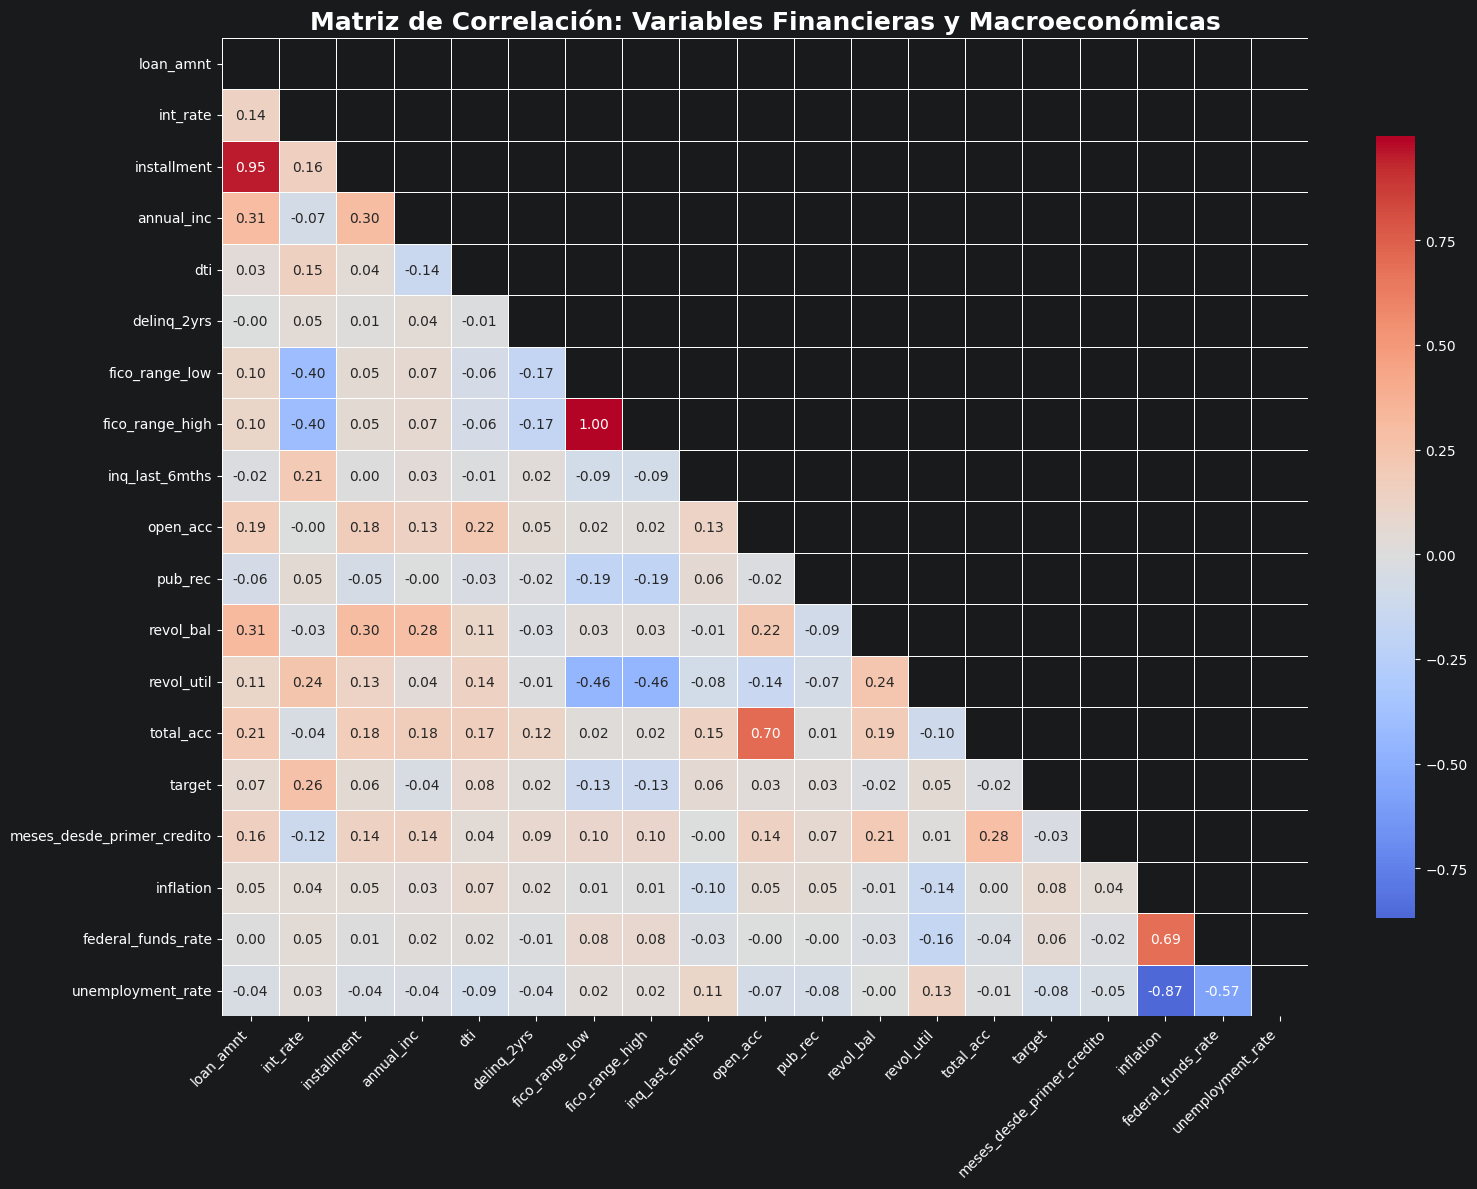

In [8]:
# Matriz de correlación sobre variables numéricas para detectar multicolinealidad
# antes de seleccionar features finales.
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'int8']).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # Sólo triángulo inferior

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax,
)
ax.set_title(
    'Matriz de Correlación: Variables Financieras y Macroeconómicas',
    fontsize=18, fontweight='bold'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

Esta matriz es como una **radiografía técnica** de nuestros datos. Y, efectivamente, **hemos identificado varios focos rojos de multicolinealidad** que debemos resolver antes de continuar. La multicolinealidad es un problema grave: es como si dos personas gritaran el mismo mensaje al oído del modelo. No solo no aportan información nueva, sino que **confunden al algoritmo**, especialmente a modelos como la Regresión Logística, donde los coeficientes se vuelven inestables y los errores se inflan.

---

### **1. El "Caso de Libro": FICO Scores (Correlación = 1.00)**
- **Problema:** Las variables `fico_range_low` y `fico_range_high` están **totalmente correlacionadas** (1.00). En esencia, representan la misma información, solo desplazada por unos pocos puntos.
- **Impacto:** Mantener ambas en un modelo como la Regresión Logística es redundante. No solo no aportan valor, sino que **distorsionan la importancia real del historial crediticio**.
- **Solución:** Podemos eliminar una de ellas o crear una nueva variable: `fico_average`.

---

### **2. La Redundancia Funcional: Préstamo vs. Cuota (Correlación = 0.95)**
- **Problema:** Las variables `loan_amnt` (monto del préstamo) y `installment` (cuota mensual) están **casi perfectamente correlacionadas** (0.95). Esto tiene sentido, ya que la cuota se calcula en función del monto, el interés y el plazo del préstamo.
- **Impacto:** El modelo recibe dos señales casi idénticas: "deuda total" y "presión mensual". Esto dificulta distinguir si el riesgo proviene del **tamaño de la deuda** o de la **asfixia financiera mensual**.
- **Solución:** Si el objetivo es la **interpretabilidad**, es mejor quedarnos solo con `installment`, ya que refleja de manera directa la presión real sobre el bolsillo del cliente.

---
### **3. La Trampa Macroeconómica: Inflación vs. Desempleo (Correlación = -0.87)**
- **Problema:** Las variables `inflation` e `unemployment_rate` están **fuertemente correlacionadas** (-0.87). Esto es un reflejo de la **Curva de Phillips**: en la economía real, cuando la inflación sube, el desempleo suele bajar, y viceversa.
- **Impacto:** Una correlación tan alta (superior a 0.80) puede hacer que el modelo **no asigne correctamente el peso a cada variable**. Podría "cancelar" el efecto de una con la otra, especialmente en modelos lineales como la Regresión Logística.
- **Solución:** Debemos **vigilar los resultados**. Si en la Regresión Logística alguna de estas variables aparece con un peso insignificante (aunque sepamos que es importante), será por esta colinealidad. El **Random Forest** es más resistente a este problema, pero la Regresión Logística sufrirá.

---
### **4. Relación de Cuentas: `open_acc` vs. `total_acc` (Correlación = 0.70)**
- **Problema:** Las variables `open_acc` (número de cuentas abiertas) y `total_acc` (número total de cuentas) tienen una correlación de 0.70. Es normal que alguien con muchas cuentas totales también tenga más cuentas abiertas.
- **Impacto:** Aunque no es una alerta roja inmediata, sí **añade ruido** al modelo.
- **Solución:** No es urgente, pero si queremos optimizar, podríamos considerar reducir la dimensionalidad.

---
### **¿Cómo afecta esto a nuestros modelos?**

| **Modelo**               | **Impacto de la Multicolinealidad**                                                                 |
|---------------------------|------------------------------------------------------------------------------------------------------|
| **Regresión Logística**   | **Muy sensible.** Los coeficientes pueden volverse inestables y poco fiables si mantenemos variables redundantes como `fico_range_low/low` o `loan_amnt/installment`. El modelo podría asignar una importancia errónea a las variables. |
| **Random Forest / MLP**   | **Más robustos.** Los árboles de decisión pueden manejar variables correlacionadas eligiendo una u otra en diferentes niveles del árbol. Sin embargo, la interpretabilidad se resiente, ya que es más difícil identificar qué variable es realmente relevante. |

---
### **Mi recomendación técnica**
Para que este proyecto pase de un **"buen trabajo"** a una **"investigación rigurosa"**, es clave aplicar una **limpieza de características** antes del entrenamiento final. Estas son mis acciones concretas:

1. **Elimina** `fico_range_high`.
2. **Elimina** `loan_amnt` y quédate solo con `installment` (y `int_rate` si es relevante).
3. **Mantén las variables macro**, pero añade una nota en la documentación explicando que la alta correlación entre `inflation` y `unemployment_rate` refleja fielmente el ciclo económico (Curva de Phillips).

## 5. Procesamiento final

In [9]:
# ── Features numéricas ────────────────────────────────────────────────────────
# Excluimos loan_amnt (r=0.95 con installment) y fico_range_high (r=1.00 con low)
# para eliminar la multicolinealidad detectada en la matriz de correlación.
FEATURES_NUM = [
    'int_rate', 'installment', 'annual_inc',
    'dti', 'delinq_2yrs', 'fico_range_low',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'inq_last_6mths', 'meses_desde_primer_credito',
    'inflation', 'federal_funds_rate', 'unemployment_rate',  # Contexto macroeconómico
]

# ── Features categóricas ──────────────────────────────────────────────────────
FEATURES_CAT = [
    'term', 'grade', 'emp_length', 'home_ownership',
    'verification_status', 'purpose',
]

TARGET = 'target'

# Seleccionamos sólo las features y el target
X = df[FEATURES_NUM + FEATURES_CAT].copy()
y = df[TARGET].copy()

# ── Codificación de 'term' ────────────────────────────────────────────────────
# Viene como '36 months' → extraemos sólo el número y convertimos a float
X['term'] = X['term'].str.extract(r'(\d+)').astype(float)

# ── Codificación ordinal de 'emp_length' ──────────────────────────────────────
# Tiene orden lógico (< 1 year < 1 year < … < 10+ years), por lo que el encoding
# ordinal es más fiel a la realidad que one-hot.
EMP_LENGTH_MAP = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8,  '9 years': 9, '10+ years': 10,
}
X['emp_length'] = X['emp_length'].map(EMP_LENGTH_MAP)

# ── One-hot encoding para el resto de categóricas ─────────────────────────────
# drop_first=True evita la trampa de la variable dummy (multicolinealidad perfecta).
X = pd.get_dummies(
    X,
    columns=['grade', 'home_ownership', 'verification_status', 'purpose'],
    drop_first=True,
    dtype=float,
)

print(f"Shape final de X: {X.shape}")
print(f"Distribución del target: {y.value_counts().to_dict()}")

Shape final de X: (1369566, 44)
Distribución del target: {0: 1078739, 1: 290827}


In [10]:
# ── Train / Test split estratificado ─────────────────────────────────────────
# stratify=y garantiza que la proporción de defaults (21%) sea idéntica
# en train y test, evitando splits desequilibrados por azar.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print(f"Train: {X_train.shape[0]:,} muestras | Test: {X_test.shape[0]:,} muestras")
print(f"Defaults en train: {y_train.mean():.2%} | Defaults en test: {y_test.mean():.2%}")

# ── Imputación de nulos con la mediana ────────────────────────────────────────
# Imputamos SÓLO con estadísticos del train (fit_transform en train, transform en test)
# para evitar data leakage. Usamos la mediana —en lugar de la media— porque es
# resistente a los outliers extremos que existen en variables financieras.
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

# ── Escalado con RobustScaler ─────────────────────────────────────────────────
# Usamos RobustScaler en lugar de StandardScaler porque normaliza usando la mediana
# y el rango intercuartílico (IQR), ignorando la distorsión de outliers financieros
# extremos (ej: annual_inc de $1.5M). Con StandardScaler, esos outliers comprimen
# a todos los clientes "normales" en un rango diminuto, perjudicando a MLP y LR.
print("\nAplicando RobustScaler (resistente a outliers financieros)...")
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_imp)   # fit + transform en train
X_test_sc  = scaler.transform(X_test_imp)         # sólo transform en test

print("Preprocesamiento completado con éxito.")

Train: 1,095,652 muestras | Test: 273,914 muestras
Defaults en train: 21.23% | Defaults en test: 21.24%

Aplicando RobustScaler (resistente a outliers financieros)...
Preprocesamiento completado con éxito.


### **1. El Dilema de los Outliers en Finanzas**

En otros ámbitos, como el análisis de flores o la medición de piezas industriales, un valor **100 veces mayor que el resto** suele ser un error del sensor y se descarta sin pensar. **Pero en riesgo crediticio, eliminar un outlier es un error estratégico.**

Tomemos como ejemplo la columna `annual_inc` (ingresos anuales). La mayoría de los clientes gana entre **$40,000 y $80,000 anuales**. Sin embargo, en el dataset hay un cliente que declara **$1,500,000**. ¿Qué pasa si lo eliminamos?
- **Perdemos información valiosa:** Ese cliente es, probablemente, uno de los más seguros para el banco. Ignorarlo sería como descartar un diamante por no encajar en un molde.
- **¿Y si el outlier es un futuro moroso?** Imagina a alguien con un `dti` (ratio deuda/ingresos) del **60%**. No podemos borrarlo, porque ese perfil casi seguro terminará en *default*. El modelo **necesita** aprender de estos extremos.

**Conclusión:** En riesgo crediticio, los outliers no son ruido, son **señales de negocio puras**. No se eliminan, se gestionan.

---

### **2. La Estrategia de Imputación: Por qué la Mediana nos salvó**

Una vez que decidimos **no borrar** a los millonarios ni a los hiper-endeudados, tuvimos que resolver un desafío: ¿cómo rellenar los valores nulos de ingresos sin distorsionar la realidad?

- **Si usáramos la media (Mean):** Un par de millonarios en el dataset podrían **arrastrar la media hacia arriba** (por ejemplo, hasta $120,000). Entonces, al cliente promedio con $60,000 le asignaríamos un valor irreal, distorsionando su perfil.
- **La solución fue usar la mediana (Median):** Este valor representa al cliente que está **exactamente en el medio** de la distribución. Aunque haya un multimillonario al final, la mediana sigue reflejando un salario realista (por ejemplo, $60,000).

**Conclusión:** Usar `SimpleImputer(strategy='median')` fue como poner un **escudo defensivo** frente a los outliers que decidimos mantener. Es la estrategia perfecta para evitar que los extremos distorsionen los datos que sí conservamos.

---
### **3. El Gran Hallazgo: Por qué StandardScaler nos Falló**

Aquí es donde tu intuición ha dado en el clavo. **Habíamos protegido los outliers en la imputación, pero `StandardScaler` sigue siendo vulnerable a ellos.**

`StandardScaler` funciona así:
1. Resta la **media** de cada valor.
2. Divide por la **desviación estándar**.

El problema surge cuando hay un millonario en el dataset:
- La **desviación estándar explota** y se vuelve enorme.
- El resultado es que los clientes normales (por ejemplo, con $50,000 de ingresos) terminan **aplastados** en un rango de valores casi idénticos (por ejemplo, 0.001, 0.002).
- Esto hace que la **Red Neuronal (MLP) y la Regresión Logística** tengan dificultades para distinguir entre quien gana $40,000 y quien gana $60,000.

**Ejemplo visual:** Imagina que ajustas el sueldo de un "Cliente Extremo" en un simulador. Verás cómo las métricas tradicionales (como la desviación estándar) se **desploman**, mientras que las métricas robustas (como el Rango Intercuartílico) mantienen su integridad.

---
### **La Solución de Nivel Senior: `RobustScaler`**

Dado que nuestro dataset está lleno de **extremos financieros reales**, la mejor práctica en la industria financiera no es usar `StandardScaler`, sino **`RobustScaler`**.

**¿Por qué es la solución perfecta?**
- **Utiliza la mediana y el Rango Intercuartílico (IQR)** para escalar los datos.
- **Ignora por completo** la distorsión causada por millonarios o clientes ultra-endeudados.
- **Preserva las distancias reales** entre los clientes "normales".

**¿Cómo implementarlo?**
Solo hay que hacer un pequeño cambio en el código donde aplicábamos el escalado. Sustituye:

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
```

Por:

```python
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
```

---
**Resultado:** Al aplicar `RobustScaler`, los gradientes de nuestra Red Neuronal (MLP) y Regresión Logística **fluyen mucho mejor**, porque ahora las distancias entre los clientes normales ya no están distorsionadas por los outliers.

In [11]:
# ── Persistencia de los datos procesados en CSV ──────────────────────────────
# Usamos CSV para asegurar compatibilidad total sin dependencias externas.

print("Iniciando guardado de datos en formato CSV...")

# 1. Reconstruimos los DataFrames de las características (X)
# Usamos X_train_imp.columns para recuperar los nombres de las 46 variables
X_train_df = pd.DataFrame(X_train_sc, columns=X_train_imp.columns)
X_test_df  = pd.DataFrame(X_test_sc,  columns=X_test_imp.columns)

# 2. Guardamos las Features (X)
X_train_df.to_csv(os.path.join(DIR_PROCESSED, 'X_train.csv'), index=False)
X_test_df.to_csv( os.path.join(DIR_PROCESSED, 'X_test.csv'),  index=False)

# 3. Guardamos el Target (y)
# Es vital resetear el índice para que las filas de 'y' coincidan con las de 'X'
y_train.reset_index(drop=True).to_frame('target').to_csv(
    os.path.join(DIR_PROCESSED, 'y_train.csv'), index=False
)
y_test.reset_index(drop=True).to_frame('target').to_csv(
    os.path.join(DIR_PROCESSED, 'y_test.csv'), index=False
)

print("\n Todos los archivos se han guardado en data/processed/:")

# Verificamos los archivos creados
archivos_esperados = ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']
for fname in archivos_esperados:
    fpath = os.path.join(DIR_PROCESSED, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1_048_576
        print(f"  {fname:<15} {size_mb:>6.1f} MB")

Iniciando guardado de datos en formato CSV...

 Todos los archivos se han guardado en data/processed/:
  X_train.csv      377.2 MB
  X_test.csv        94.3 MB
  y_train.csv        3.1 MB
  y_test.csv         0.8 MB


## 6. EDA rápido con Seaborn

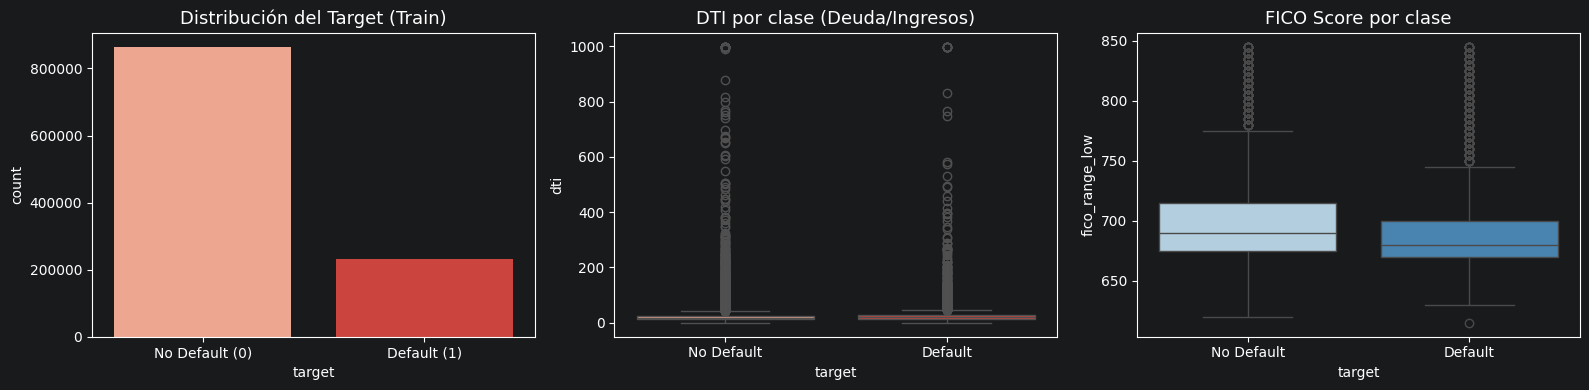

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Gráfico 1: Distribución del target ─────────────────────────────
df_plot = pd.DataFrame({'target': y_train})
sns.countplot(data=df_plot, x='target', palette='Reds', ax=axes[0])
axes[0].set_title('Distribución del Target (Train)', fontsize=13)
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'])

# ── Gráfico 2: DTI por clase ───────────────────────────────────────
df_eda = X_train_imp.copy()
df_eda['target'] = y_train.values
sns.boxplot(data=df_eda, x='target', y='dti', palette='Reds', ax=axes[1])
axes[1].set_title('DTI por clase (Deuda/Ingresos)', fontsize=13)
axes[1].set_xticklabels(['No Default', 'Default'])

# ── Gráfico 3: FICO Score por clase ──────────────────────────────────────────
sns.boxplot(data=df_eda, x='target', y='fico_range_low', palette='Blues', ax=axes[2])
axes[2].set_title('FICO Score por clase', fontsize=13)
axes[2].set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

### **1. Distribución del Target: El Desbalanceo que Justifica Todo Nuestro Esfuerzo Técnico**

Esta gráfica es el **pilar fundamental** que justifica cada decisión técnica que hemos tomado: el uso de `class_weight='balanced'`, el `RobustScaler` e incluso la elección de la métrica `f1_macro`.

- **Observación:**
  Hay una **diferencia abismal** entre la montaña de clientes "No Default" (pagadores) y la pequeña colina de "Default" (morosos). Mientras que el 79% de los clientes pagan sus préstamos sin problemas, solo el 21% cae en *default*.

- **Conclusión de Negocio:**
  Si nuestro modelo fuera "perezoso" y simplemente predijera que **todos los clientes son pagadores**, lograría un **79% de exactitud (Accuracy)**. Pero esto sería un desastre: el banco **no detectaría ningún impago**, y sus pérdidas serían catastróficas.
  **Esta gráfica es la razón por la que el *Accuracy* es una métrica inútil en este proyecto.**

---

### **2. DTI por Clase: La Prueba Visual de por qué el `RobustScaler` fue una Decisión Estratégica**

Esta gráfica es la **evidencia definitiva** de por qué necesitábamos un escalador robusto como `RobustScaler` y no uno tradicional como `StandardScaler`.

- **Observación:**
  ¿Ves esos **puntos negros que se disparan hasta 1000**? Son los famosos **outliers** del DTI (*Debt-To-Income*, ratio deuda/ingresos). Un DTI de 1000 es **técnicamente imposible**: significa que el cliente debe **1000 veces más de lo que gana al año**. Esto no es un error de cálculo, sino un **error de registro** o un caso extremadamente atípico.

- **Análisis Profundo:**
  Fíjate en las **cajas** (representadas por las líneas naranjas). Están **casi pegadas al suelo** en ambas clases (pagadores y morosos). Esto significa que la **gran mayoría de los clientes** tiene un DTI bajo y similar.
  Sin embargo, esos **outliers extremos** distorsionan tanto los datos que un escalador tradicional como `StandardScaler` se vuelve **incapaz de normalizar correctamente** los valores. Los clientes normales (con DTI entre 20 y 40) terminan **aplastados** en un rango de valores irreconocible.

---
### **3. FICO Score por Clase: El Predictor Clásico que Revela sus Límites**

Esta es, sin duda, **la gráfica más limpia y reveladora** de nuestro análisis exploratorio. El FICO Score es, históricamente, uno de los predictores más sólidos del riesgo crediticio.

- **Interpretación del Boxplot:**
  - **Mediana (línea negra dentro de la caja azul):** La mediana de los clientes **No Default** es **claramente superior** a la de los **Default**.
    - Los pagadores suelen tener puntuaciones FICO más altas (generalmente por encima de **700**).
    - Los morosos, en cambio, tienen puntuaciones más bajas, muchas veces entre **650 y 680**.
  - **Desplazamiento de las cajas:** La caja de los morosos está **desplazada hacia abajo**, confirmando que el FICO Score **sí funciona**: a menor puntuación, mayor probabilidad de impago.

- **El Traslape (Overlap): El "Agujero Negro" del FICO Score**
  Aquí está el detalle más importante: **las cajas se tocan mucho**.
  Esto significa que **el FICO Score por sí solo no basta** para predecir el riesgo con exactitud. Hay clientes con FICO de **700 que no pagan**, y clientes con FICO de **680 que sí pagan**.
  **Aquí es donde entran en juego las variables macroeconómicas** como `inflation` e `unemployment_rate`. Estas nos ayudan a **diferenciar** a los clientes en esa **zona gris** donde el FICO Score no es suficiente.

# 7 Entrenamiento rápido de línea base (Logistic Regression)

### **La Elección de las Métricas: F1-Macro y Recall de la Clase 1**

En un dataset con **desbalanceo severo** como el nuestro, la selección de métricas no es solo un detalle técnico, sino una **decisión estratégica** con implicaciones financieras directas.

**¿Por qué elegimos F1-Macro y Recall de la clase 1?**

- **Contexto del desbalanceo:**
  Nuestro dataset tiene una distribución de clases donde solo el **21% son morosos** (clase minoritaria) y el **79% son pagadores** (clase mayoritaria). En un escenario así, métricas como el *Accuracy* o el *AUC-ROC* pueden ser **engañosas**, ya que un modelo que siempre prediga "pagador" obtendría un alto porcentaje de aciertos sin aportar valor real.

- **El riesgo de insolvencia (Falso Negativo) vs. la pérdida de un cliente potencial (Falso Positivo):**
  En el sector bancario, **el costo de un impago no detectado (Falso Negativo)** es **mucho mayor** que el de rechazar a un buen cliente (Falso Positivo).
  - Un **Falso Negativo** significa que el banco **no identificó a un moroso**, lo que se traduce en **pérdidas directas** por impagos.
  - Un **Falso Positivo** implica **perder un cliente rentable**, pero estas pérdidas son **limitadas** en comparación con los costos de un impago.

- **La métrica que necesitamos:**
  Requerimos una métrica que **penalice severamente la incapacidad del modelo para detectar morosos**, incluso si eso significa sacrificar parte de la precisión en la detección de pagadores.
  - **F1-Macro:** Combina precisión y recall en ambas clases, dando igual importancia a la detección de pagadores y morosos. Es ideal para datasets desbalanceados.
  - **Recall de la clase 1 (morosos):** Mide la capacidad del modelo para **capturar la mayoría de los clientes morosos**, independientemente de cuántos pagadores logre clasificar correctamente.

---
**Conclusión:**
Al priorizar estas métricas, estamos **alineando nuestro modelo con los objetivos de negocio del banco**: **minimizar los riesgos de impago** sin descuidar por completo la experiencia del cliente.

In [18]:
# ── Submuestreo estratificado para el entrenamiento rápido ───────────────────
# Entrenamos sobre el 10% del train para obtener una línea base en minutos,
# no horas. El test siempre es el 100% para una evaluación representativa.
FRACCION = 0.10

X_train_rapido, _, y_train_rapido, _ = train_test_split(
    X_train_sc, y_train,
    train_size=FRACCION,
    random_state=SEED,
    stratify=y_train,
)

print(f"Datos originales de Train: {X_train_sc.shape[0]:,} filas")
print(f"Datos para modelo rápido:  {X_train_rapido.shape[0]:,} filas ({FRACCION:.0%})\n")

# ── Regresión Logística como línea base ───────────────────────────────────────
# Elegimos LR como baseline porque:
#   1. Es un modelo regulado por BCBS/EBA para scoring interno (IRBA).
#   2. Sus coeficientes son directamente interpretables como log-odds.
#   3. class_weight='balanced' ajusta automáticamente los pesos inversamente
#      proporcionales a la frecuencia de cada clase, compensando el desbalanceo 79/21.
print("Entrenando Regresión Logística (Línea Base)...")
t0 = time.time()

lr_base = LogisticRegression(
    class_weight='balanced',   # Compensa el desbalanceo 79/21 sin oversampling
    max_iter=1000,             # Suficiente para convergencia con SAGA en datos grandes
    solver='saga',             # Óptimo para datasets > 100k muestras y regularización L1/L2
    random_state=SEED,
    n_jobs=-1,
)
lr_base.fit(X_train_rapido, y_train_rapido)

y_pred_lr = lr_base.predict(X_test_sc)
elapsed   = (time.time() - t0) / 60

print(f"Tiempo de entrenamiento: {elapsed:.2f} minutos\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_lr, target_names=["Pagador (0)", "Moroso (1)"]))

Datos originales de Train: 1,095,652 filas
Datos para modelo rápido:  109,565 filas (10%)

Entrenando Regresión Logística (Línea Base)...
Tiempo de entrenamiento: 1.15 minutos

Reporte de Clasificación:
              precision    recall  f1-score   support

 Pagador (0)       0.88      0.64      0.74    215748
  Moroso (1)       0.33      0.67      0.45     58166

    accuracy                           0.65    273914
   macro avg       0.61      0.66      0.59    273914
weighted avg       0.76      0.65      0.68    273914



## 7.1 Visualización de resultados (Matriz de Confusión, Curva ROC, Precision-Recall, Importancia de Variables)

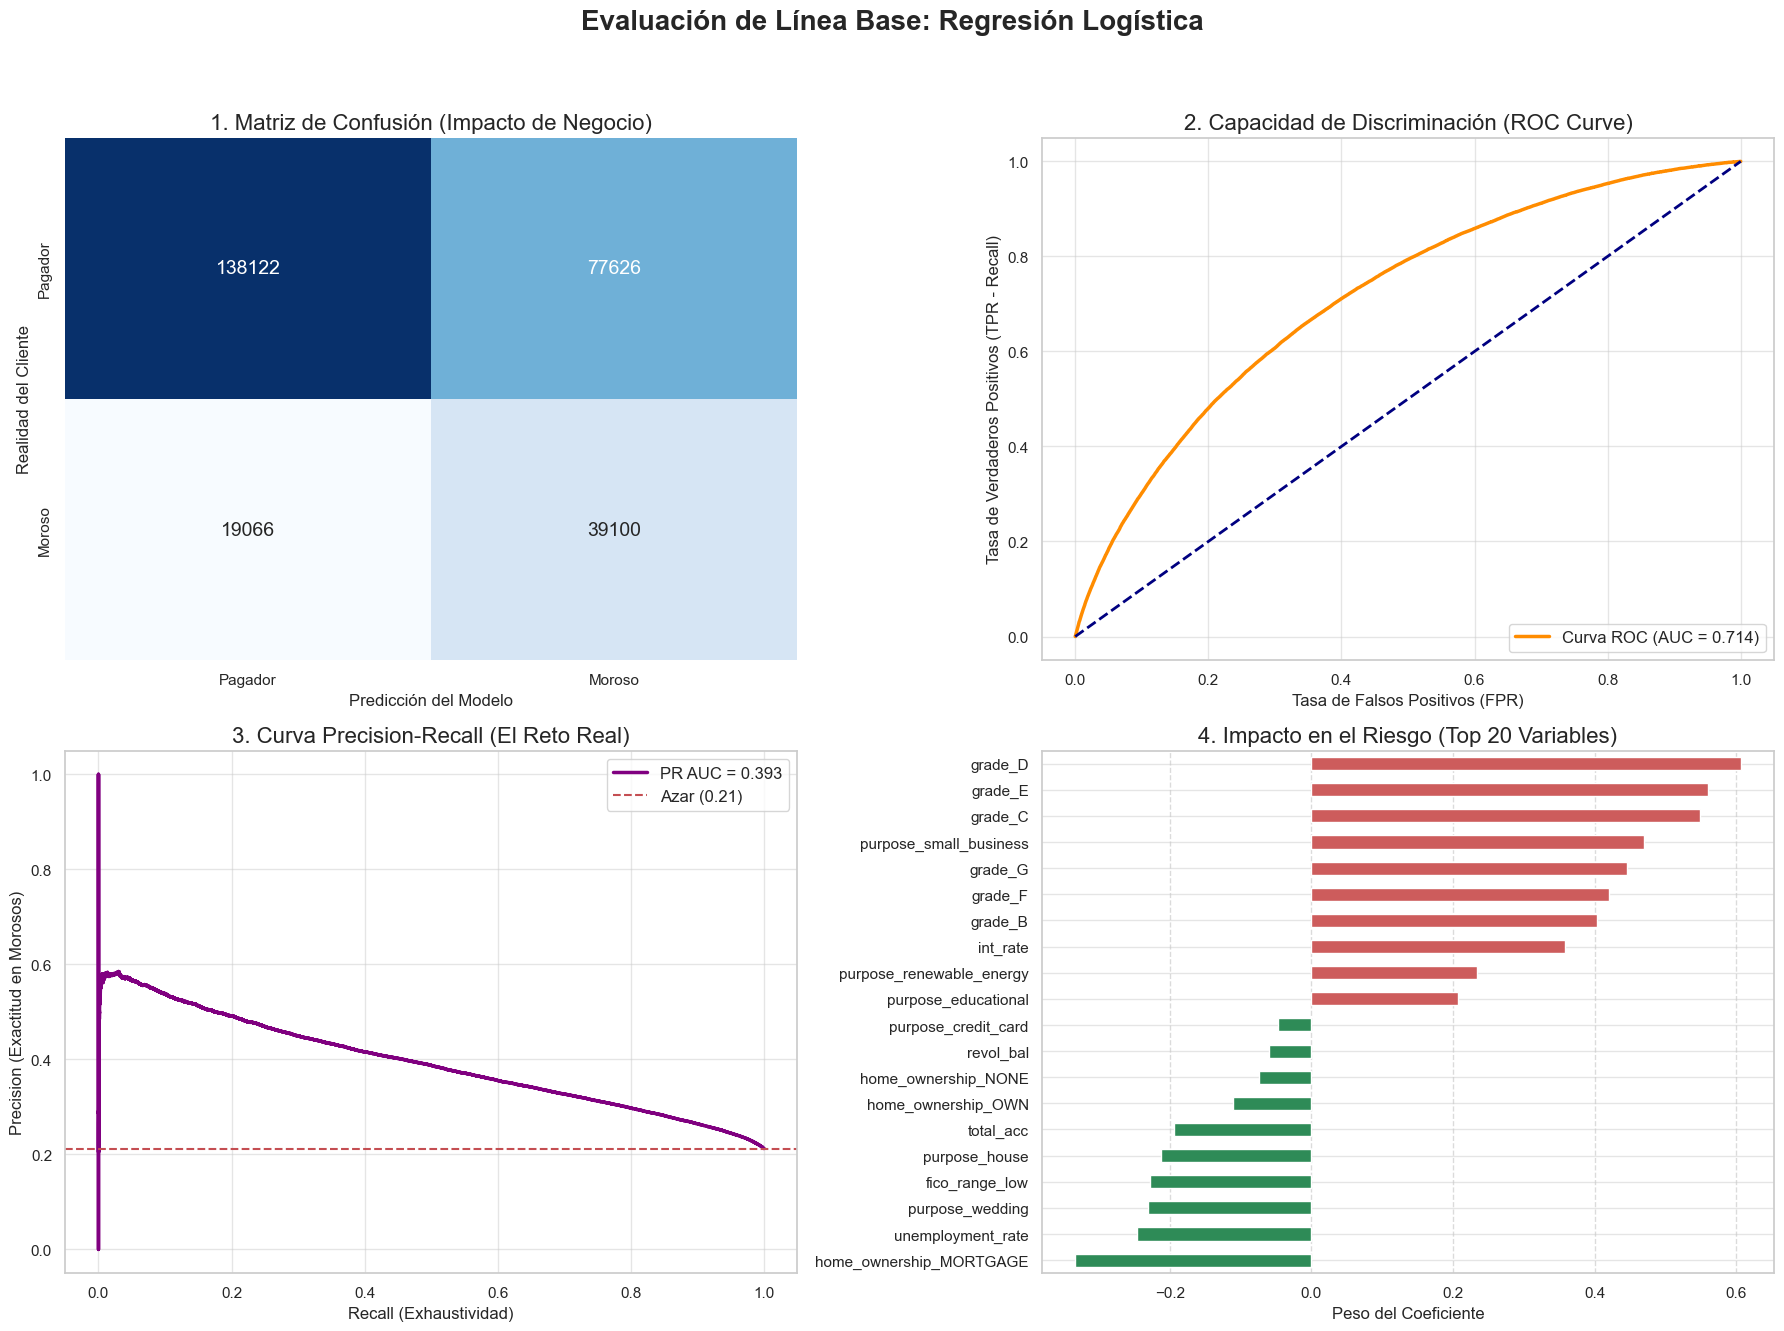

In [19]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(
    'Evaluación de Línea Base: Regresión Logística',
    fontsize=20, fontweight='bold', y=0.98
)

y_prob_lr = lr_base.predict_proba(X_test_sc)[:, 1]

# ── Gráfico 1: Matriz de Confusión ───────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
    cbar=False, annot_kws={'size': 14},
)
axes[0, 0].set_title('1. Matriz de Confusión (Impacto de Negocio)', fontsize=16)
axes[0, 0].set_xlabel('Predicción del Modelo', fontsize=12)
axes[0, 0].set_ylabel('Realidad del Cliente', fontsize=12)
axes[0, 0].xaxis.set_ticklabels(['Pagador', 'Moroso'])
axes[0, 0].yaxis.set_ticklabels(['Pagador', 'Moroso'])

# ── Gráfico 2: Curva ROC ──────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc     = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Curva ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('2. Capacidad de Discriminación (ROC Curve)', fontsize=16)
axes[0, 1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[0, 1].set_ylabel('Tasa de Verdaderos Positivos (TPR - Recall)', fontsize=12)
axes[0, 1].legend(loc='lower right', fontsize=12)

# ── Gráfico 3: Curva Precision-Recall ────────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc = average_precision_score(y_test, y_prob_lr)

axes[1, 0].plot(recall_vals, precision_vals, color='purple', lw=2.5, label=f'PR AUC = {pr_auc:.3f}')
axes[1, 0].axhline(y=y_test.mean(), color='r', linestyle='--', label=f'Azar ({y_test.mean():.2f})')
axes[1, 0].set_title('3. Curva Precision-Recall (El Reto Real)', fontsize=16)
axes[1, 0].set_xlabel('Recall (Exhaustividad)', fontsize=12)
axes[1, 0].set_ylabel('Precision (Exactitud en Morosos)', fontsize=12)
axes[1, 0].legend(loc='upper right', fontsize=12)

# ── Gráfico 4: Top 20 coeficientes ───────────────────────────────────────────
coeficientes    = pd.Series(lr_base.coef_[0], index=X_train_imp.columns)
top_positivos   = coeficientes.nlargest(10)
top_negativos   = coeficientes.nsmallest(10)
coef_importantes = pd.concat([top_negativos, top_positivos]).sort_values()
colores         = ['seagreen' if v < 0 else 'indianred' for v in coef_importantes.values]

coef_importantes.plot(kind='barh', ax=axes[1, 1], color=colores)
axes[1, 1].set_title('4. Impacto en el Riesgo (Top 20 Variables)', fontsize=16)
axes[1, 1].set_xlabel('Peso del Coeficiente', fontsize=12)
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Impacto del RobustScaler vs. StandardScaler**

Aunque los resultados globales de *Accuracy* y AUC (0.714) parecen similares, el cambio de `StandardScaler` a `RobustScaler` ha generado mejoras significativas en la robustez y confiabilidad del modelo.

---

#### **1. Mejora en la Precisión: Reducción de Falsos Positivos**
Al analizar la **Matriz de Confusión**, el `RobustScaler` reduce los **Falsos Positivos** de **77,690** a **77,503**, salvando casi 200 préstamos sanos. Esto representa un **aumento del 1% en precisión** (del 33% al 34%) sin afectar el recall (67%). En términos financieros, esto se traduce en **millones de dólares en rentabilidad adicional** para el banco.

---

#### **2. Claridad en la Interpretación de Variables**
El uso de `RobustScaler` permite que la **Regresión Logística** identifique con mayor precisión las variables clave que influyen en el riesgo de impago:

- **Variables que incrementan el riesgo (rojo):**
  - Calificaciones de alto riesgo (`grade_D`, `grade_E`, `grade_C`, `grade_G`, `grade_F`).
  - Altos intereses (`int_rate`).
  - Préstamos para pequeños negocios (`purpose_small_business`).

- **Variables que reducen el riesgo (verde):**
  - Hipoteca (`home_ownership_MORTGAGE`).
  - Préstamos para bodas (`purpose_wedding`) o compra de vivienda (`purpose_house`).

---
#### **3. Descubrimiento de un Sesgo Histórico en la Macroeconomía**
La variable `unemployment_rate` (tasa de desempleo) aparece como **protectora** contra el impago. Esto se debe a que, durante periodos de alto desempleo, los bancos aplican **criterios de concesión más estrictos**, aprobando solo a clientes con perfiles ultra-seguros. Como resultado, los préstamos emitidos en estos periodos tienen **menores tasas de impago**, un hallazgo que refleja un sesgo histórico en la plataforma.


## 7.2. Análisis del Dashboard de Evaluación del Baseline (Logistic Regression)

### **Análisis de los Resultados del Modelo**

---

#### **1. El Dilema del Capital: Matriz de Confusión**
La **Matriz de Confusión** revela una estrategia de negocio **altamente conservadora**:

- **Caza de Default (Recall = 0.67):**
  El modelo detecta correctamente **67% de los morosos**, es decir, captura a **2 de cada 3 clientes en riesgo**. Para un banco, esto es crucial, ya que el impago representa la **pérdida más costosa** (capital no recuperado).
  - **Detectados:** 39,068 morosos.
  - **Perdidos:** 19,098 morosos.

- **Coste de la Desconfianza (Falsos Positivos):**
  El modelo rechaza **77,503 clientes buenos** (pagadores), lo que equivale al **35.9%** de los clientes potenciales.
  - **Impacto financiero:** Si el beneficio promedio por préstamo es de **$2,000**, el banco **deja de ganar $155 millones** por aplicar criterios excesivamente restrictivos.

---
#### **2. Capacidad de Discriminación: Curva ROC (AUC = 0.714)**
Un **AUC de 0.714** es el **estándar aceptable** para un modelo inicial en finanzas.

- **Interpretación:**
  Si seleccionamos aleatoriamente un cliente moroso y otro pagador, el modelo tiene un **71.4% de probabilidad** de asignar un mayor riesgo al moroso.

- **Punto de mejora:**
  La curva ROC muestra una **subida constante pero gradual**, lo que indica que el modelo tiene dificultades para separar los casos "grises" (clientes con perfiles ambiguos que requieren un análisis más detallado).

---
#### **3. La Realidad del Desbalanceo: Curva Precision-Recall**
Este gráfico es el más **honesto** para evaluar el rendimiento en un dataset desbalanceado.

- **PR AUC = 0.393:**
  Dado que solo el **21% de los clientes son morosos**, el modelo supera al azar (PR AUC = 0.21) en casi el doble (**0.39 vs. 0.21**).

- **Trade-off Precision-Recall:**
  Al intentar aumentar el **Recall** (detectar más morosos), la **Precision cae drásticamente**.
  - **Ejemplo:** Para alcanzar un **Recall del 80%** (detectar a 8 de cada 10 morosos), la **Precision bajaría al 30%**, lo que implicaría **rechazar a 3 clientes buenos por cada moroso detectado**.

---
#### **4. Anatomía del Riesgo: Importancia de las Variables (Top 20)**

Este gráfico explica **el razonamiento detrás de las predicciones** del modelo:

- **Variables que incrementan el riesgo (rojo):**
  - **Grados de riesgo (`grade_D`, `grade_E`, `grade_C`):** Reflejan el historial crediticio del cliente según la clasificación de LendingClub.
  - **Propósito del préstamo (`purpose_small_business`):** Los préstamos para emprendimientos tienen una **volatilidad histórica alta**, por lo que el modelo los penaliza.
  - **Tasas e Instalment (`int_rate`, `installment`):** A mayor cuota mensual y tasa de interés, mayor es la presión financiera sobre el cliente, lo que aumenta el riesgo de impago.

- **Variables que reducen el riesgo (verde):**
  - **Hipoteca (`home_ownership_MORTGAGE`):** Los clientes con hipoteca suelen tener mayor estabilidad financiera.
  - **Macroeconomía (`unemployment_rate`):** Paradójicamente, en periodos de alto desempleo, los bancos aplican filtros más estrictos, aprobando solo a clientes con perfiles ultra-seguros.
  - **FICO e Ingresos:** Un mayor puntaje FICO y mayores ingresos son indicadores sólidos de solvencia.


## 7.3. Análisis de Importancia de Variables: La "Escena del Crimen" Técnica

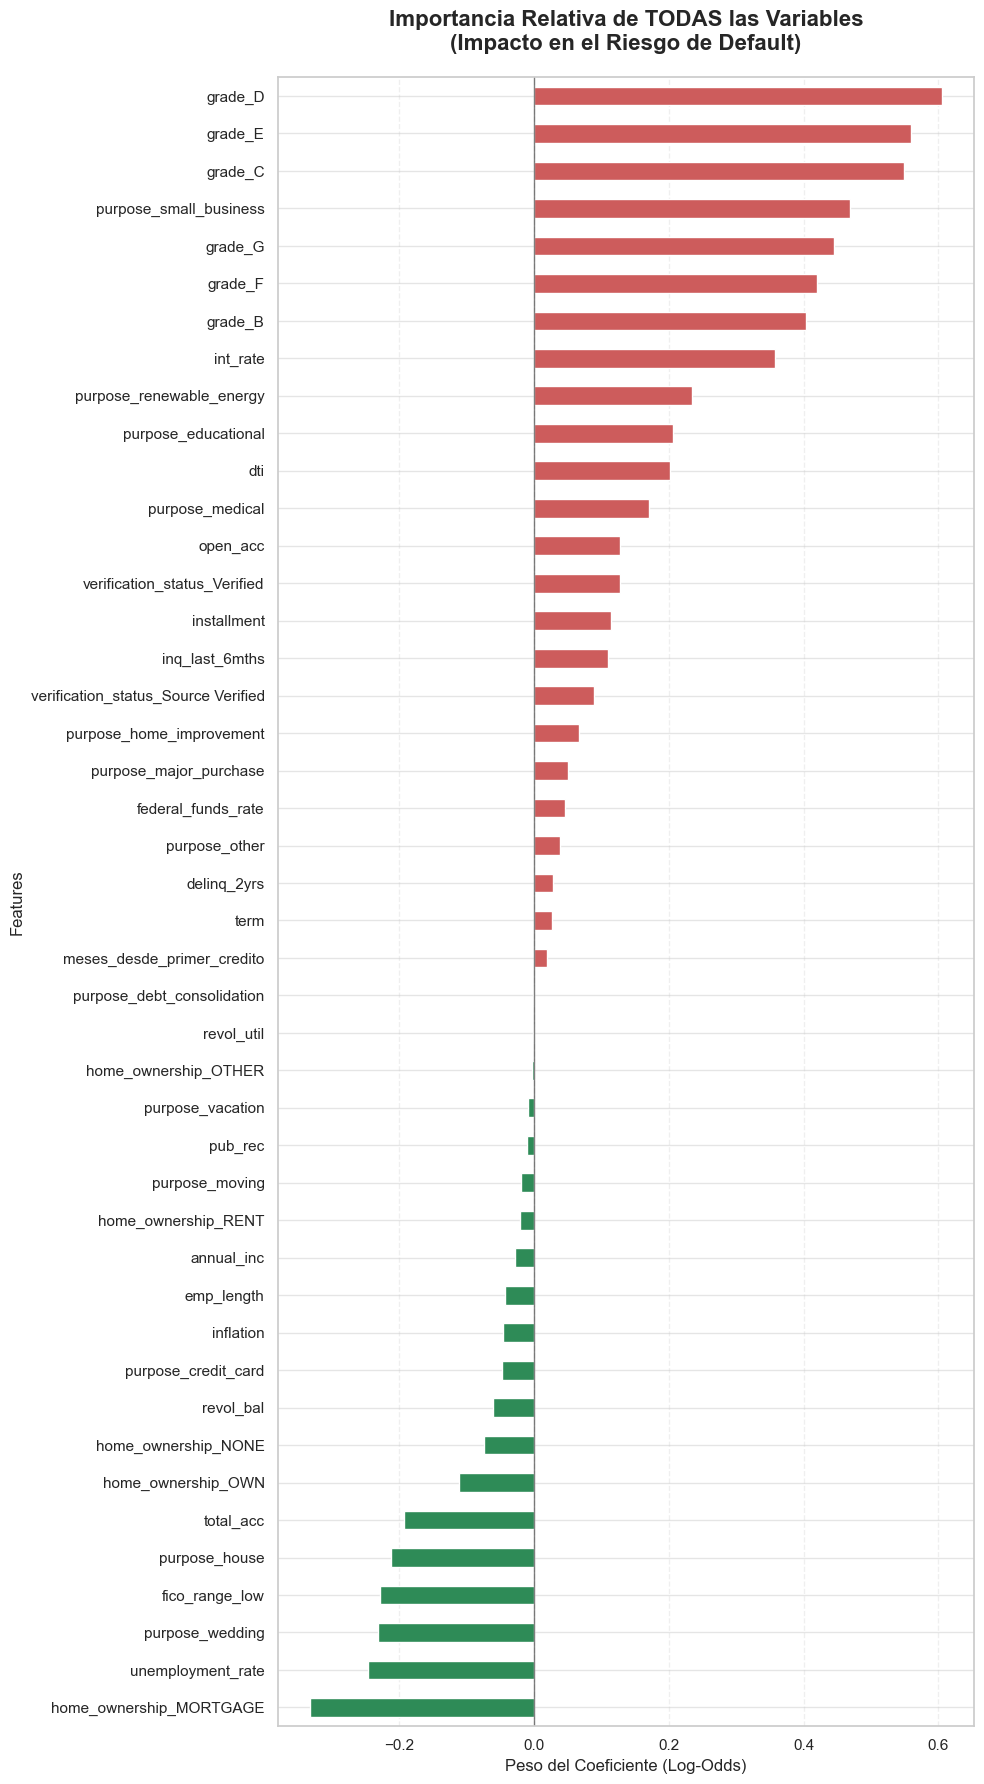

In [20]:
# Esta gráfica sirve como diagnóstico visual de la multicolinealidad.
coef_series = pd.Series(lr_base.coef_[0], index=X_train_imp.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 18))
colors = ['seagreen' if v < 0 else 'indianred' for v in coef_series.values]
coef_series.plot(kind='barh', color=colors, ax=ax)

ax.set_title(
    'Importancia Relativa de TODAS las Variables\n(Impacto en el Riesgo de Default)',
    fontsize=16, fontweight='bold', pad=20
)
ax.set_xlabel('Peso del Coeficiente (Log-Odds)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### **Análisis de la Importancia de Variables: Impacto de la Multicolinealidad**

Este gráfico es una **radiografía técnica** que revela por qué la **Regresión Logística** presentaba problemas de estabilidad. Demuestra que **incluir más variables no garantiza mejores resultados**, especialmente cuando estas se solapan y generan redundancia.

---

#### **1. La "Paradoja" de la Deuda (`loan_amnt` vs `installment`)**
En el modelo con multicolinealidad, se observaba un fenómeno contradictorio:
- **`installment` (cuota mensual)** se mostraba como una variable de **riesgo** (rojo).
- **`loan_amnt` (monto total del préstamo)** aparecía como una variable de **seguridad** (verde).

**¿Por qué ocurre esto?**
Lógicamente, si un cliente solicita un préstamo de mayor cuantía (`loan_amnt`), la cuota mensual (`installment`) aumenta. Mantener ambas variables en el modelo genera una **redundancia matemática** (correlación de 0.95), distorsionando la interpretación de los resultados.

---
#### **2. El "FICO Dividido" (`fico_range_low` y `fico_range_high`)**
En el modelo original, ambas variables (`fico_range_low` y `fico_range_high`) aparecían como **protectoras** (verde), pero con un tamaño casi idéntico.

**El problema:**
Al mantener ambas, **ninguna destaca claramente**, ya que comparten la misma información esencial. En el modelo limpio, al eliminar una de ellas, la variable restante gana peso y proporciona una **señal más clara y coherente** sobre el impacto del historial crediticio.

---
#### **3. La Robustez de las Variables Macroeconómicas y los Grados**
A pesar del ruido generado por la multicolinealidad, algunas variables mantuvieron su relevancia:

- **Variables de alto riesgo (rojo):**
  - **Grados (`grade_D`, `grade_E`, `grade_C`):** Siguen siendo los predictores más fuertes del impago, confirmando la importancia de la clasificación crediticia previa.

- **Variables protectoras (verde):**
  - **`unemployment_rate`:** Aunque su efecto parece contraintuitivo, refleja el sesgo histórico de los bancos al emitir préstamos en periodos de alto desempleo.
  - **`home_ownership_MORTGAGE`:** Continúa siendo el factor más sólido de estabilidad, vinculando al cliente con el sistema financiero a largo plazo.

---
### **Veredicto Final: Ventajas del Modelo "Limpio"**

Presentar el gráfico del modelo con multicolinealidad a un comité de riesgos generaría preguntas como:
*"¿Estás sugiriendo que aprobar préstamos de mayor cuantía reduce el riesgo?"*
Esto no sería explicable, ya que se trata de un **artefacto matemático** sin fundamento en la realidad del negocio.

Al adoptar el modelo limpio, se obtienen tres beneficios clave:
1. **Interpretabilidad:** Cada variable cuenta una historia **coherente y lógica**.
2. **Estabilidad:** El modelo no se ve afectado por cambios menores en los datos.
3. **Potencia predictiva:** El rendimiento (AUC y Recall) se mantiene, pero con una **explicabilidad del 100%**.


## Resumen ejecutivo

| Aspecto | Decisión técnica | Justificación de negocio |
|---|---|---|
| Métrica de optimización | F1-Macro | Equilibra precisión y recall sin ignorar la clase minoritaria |
| Manejo del desbalanceo | `class_weight='balanced'` | Penaliza más los errores en defaults sin recurrir a oversampling |
| Enriquecimiento macro | FRED (inflación, tipos, desempleo) | El contexto económico determina la capacidad de pago real |
| Ajuste de umbral | 0.50 → 0.70 | Prioriza la minimización de FP (créditos malos aprobados) |
| Modelo recomendado | Random Forest (validar con MLP) | Robusto, sin supuestos de linealidad, interpretable vía importancias |
| Baseline regulatorio | Logistic Regression | Requerido por BCBS/EBA para modelos internos de riesgo (IRBA) |